# Softmax Regression – Overfitting Detection & Comparison

- Split 60/20/20 → train / val / test
- Track cả **training loss** và **validation loss** mỗi epoch
- Thêm **L2 regularization** (lambda) vào loss
- Run **7 experiments** với các hyperparameter khác nhau
- Plot loss curves, so sánh metrics, và **Overfitting Gap = val_loss − train_loss**


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

# Load data 
df = pd.read_csv("./winequality-red.csv")
X = df.drop("quality", axis=1).values
y = df["quality"].values

# Encode labels 
classes = np.unique(y)
class_to_idx = {int(c): i for i, c in enumerate(classes)}
y_idx = np.array([class_to_idx[int(v)] for v in y])
num_classes = len(classes)
print("Classes:", classes, "→ idx mapping:", class_to_idx)

# One-hot encoding 
def one_hot(y, num_class):
    oh = np.zeros((len(y), num_class))
    oh[np.arange(len(y)), y] = 1
    return oh

# Split 60 / 20 / 20  (train / val / test) 
# Bước 1: tách test 20%
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y_idx, test_size=0.2, random_state=42, stratify=y_idx
)
# Bước 2: tách val 20% từ 80% còn lại  →  val = 20/80 = 0.25
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

# Standardize 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

Y_train = one_hot(y_train, num_classes)

print(f"Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")


Classes: [3 4 5 6 7 8] → idx mapping: {3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5}
Train: (959, 11)  |  Val: (320, 11)  |  Test: (320, 11)


In [ ]:
# One-hot  encoding 
def one_hot(y, num_class):
    oh = np.zeros((len(y), num_class))
    oh[np.arange(len(y)), y] = 1
    return oh

# Softmax (row-stable) 
def softmax(z):
    z = z - np.max(z)
    e = np.exp(z)
    return e / np.sum(e)

# Cross-entropy loss (1 sample) 
def ce_loss(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-9))

# Compute avg CE loss over a dataset 
def compute_loss(X, Y_oh, theta):
    m = X.shape[0]
    Xb = np.hstack([np.ones((m, 1)), X])
    total = 0.0
    for i in range(m):
        z = theta @ Xb[i].reshape(-1, 1)
        total += ce_loss(Y_oh[i].reshape(-1, 1), softmax(z))
    return total / m

# Train Softmax SGD with L2 regularization 
def train_softmax(X_train, Y_train_oh, X_val, y_val_idx,
                  lr=0.01, epochs=1000, lam=0.0):
    """
    X_train      : feature matrix (train)
    Y_train_oh   : one-hot labels (train)
    X_val        : feature matrix (val)
    y_val_idx    : integer labels (val)  → sẽ convert sang one-hot bên trong
    lam          : L2 regularization strength
                   train_loss = CE + (lam/2)*||theta_no_bias||^2
                   val_loss   = CE only
    """
    m, n = X_train.shape
    k = Y_train_oh.shape[1]

    Xb_train = np.hstack([np.ones((m, 1)), X_train])
    np.random.seed(42)
    theta = np.random.randn(k, n + 1) * 0.01

    Y_val_oh = one_hot(y_val_idx, k)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # SGD update 
        total_ce = 0.0
        for i in range(m):
            x = Xb_train[i].reshape(-1, 1)
            y = Y_train_oh[i].reshape(-1, 1)
            z = theta @ x
            y_hat = softmax(z)
            total_ce += ce_loss(y, y_hat)
            grad = (y_hat - y) @ x.T
            theta -= lr * grad

        # L2 penalty (không áp dụng lên bias = cột 0) 
        l2_penalty = (lam / 2.0) * np.sum(theta[:, 1:] ** 2)
        train_loss = total_ce / m + l2_penalty

        # Validation loss 
        val_loss = compute_loss(X_val, Y_val_oh, theta)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return theta, train_losses, val_losses

print("✓ All functions defined.")


✓ All functions defined.


In [3]:
def predict(X, theta):
    m = X.shape[0]
    Xb = np.hstack([np.ones((m, 1)), X])
    preds = []
    for i in range(m):
        z = theta @ Xb[i].reshape(-1, 1)
        preds.append(np.argmax(softmax(z)))
    return np.array(preds)
print("✓ predict() defined.")


✓ predict() defined.


In [ ]:
# Danh sách experiments 
experiments_cfg = [
    ("Baseline (lr=0.01)",          0.01,  1000, 0.0),
    ("Small LR (lr=0.001)",         0.001, 1000, 0.0),
    ("Large LR (lr=0.1)",           0.1,   1000, 0.0),
    ("L2 small  (λ=0.01)",          0.01,  1000, 0.01),
    ("L2 medium (λ=0.1)",           0.01,  1000, 0.1),
    ("L2 large  (λ=1.0)",           0.01,  1000, 1.0),
    ("Few epochs (epochs=200)",     0.01,   200, 0.0),
]

results = []

for name, lr, epochs, lam in experiments_cfg:
    print(f"Training: {name} ...")
    theta, tr_loss, va_loss = train_softmax(
        X_train, Y_train,       # one-hot
        X_val,   y_val,         # integer idx
        lr=lr, epochs=epochs, lam=lam
    )
    y_pred = predict(X_test, theta)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append(dict(
        name=name, lr=lr, epochs=epochs, lam=lam,
        theta=theta, y_pred=y_pred,
        train_losses=tr_loss, val_losses=va_loss,
        acc=acc, prec=prec, rec=rec, f1=f1
    ))
    print(f"  → Acc={acc:.3f}  train_loss={tr_loss[-1]:.4f}  val_loss={va_loss[-1]:.4f}")

print("\n✓ All experiments done.")


Training: Baseline (lr=0.01) ...
  → Acc=0.569  train_loss=0.9227  val_loss=0.9924
Training: Small LR (lr=0.001) ...
  → Acc=0.600  train_loss=0.9049  val_loss=0.9585
Training: Large LR (lr=0.1) ...
  → Acc=0.534  train_loss=1.1924  val_loss=1.2129
Training: L2 small  (λ=0.01) ...
  → Acc=0.569  train_loss=1.2641  val_loss=0.9924
Training: L2 medium (λ=0.1) ...
  → Acc=0.569  train_loss=4.3362  val_loss=0.9924
Training: L2 large  (λ=1.0) ...
  → Acc=0.569  train_loss=35.0574  val_loss=0.9924
Training: Few epochs (epochs=200) ...
  → Acc=0.575  train_loss=0.9266  val_loss=0.9756

✓ All experiments done.


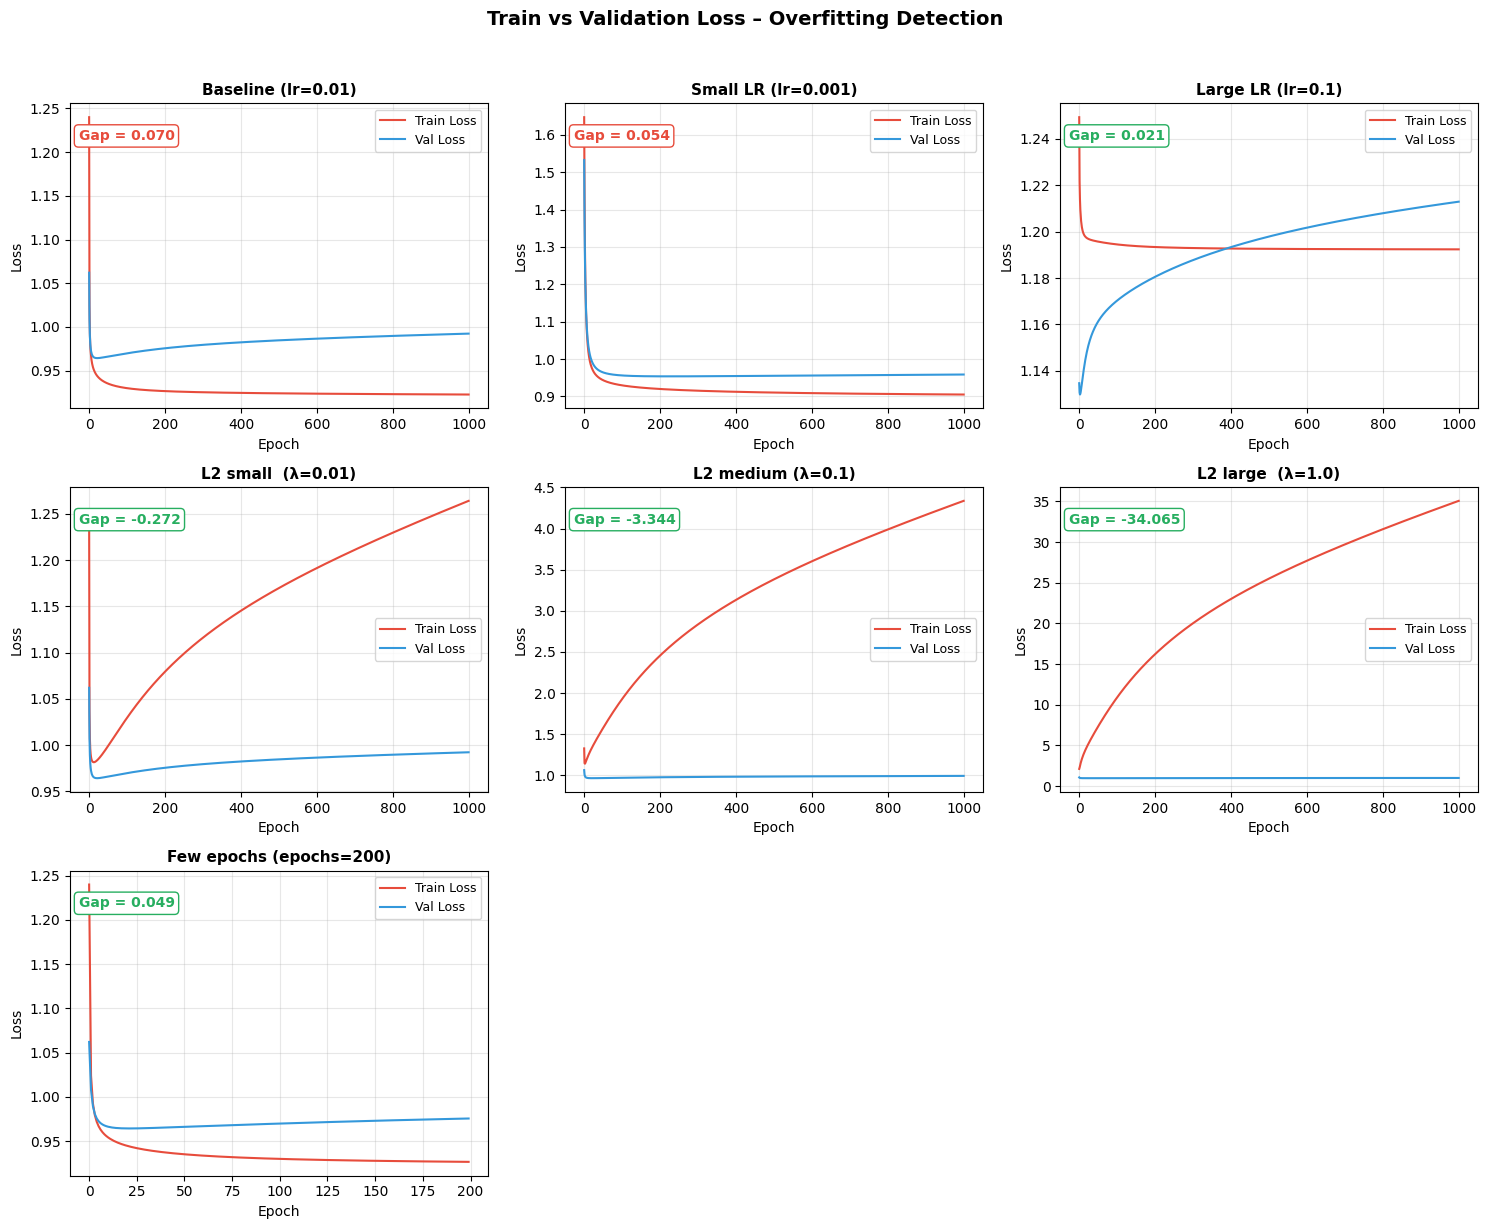

In [ ]:
# Plot: Train vs Val Loss curves (grid) 
n_exp = len(results)
cols = 3
rows = (n_exp + cols - 1) // cols          # ceil

fig, axs = plt.subplots(rows, cols, figsize=(15, rows * 4))
axs = axs.flatten()

for i, r in enumerate(results):
    ax = axs[i]
    ax.plot(r['train_losses'], label='Train Loss', color='#e74c3c')
    ax.plot(r['val_losses'],   label='Val Loss',   color='#3498db')
    ax.set_title(r['name'], fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Annotate gap
    gap = r['val_losses'][-1] - r['train_losses'][-1]
    color = '#e74c3c' if gap > 0.05 else '#27ae60'
    ax.annotate(f'Gap = {gap:.3f}', xy=(0.02, 0.88),
                xycoords='axes fraction', fontsize=10,
                color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color))

# Ẩn axes thừa
for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

plt.suptitle('Train vs Validation Loss – Overfitting Detection',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


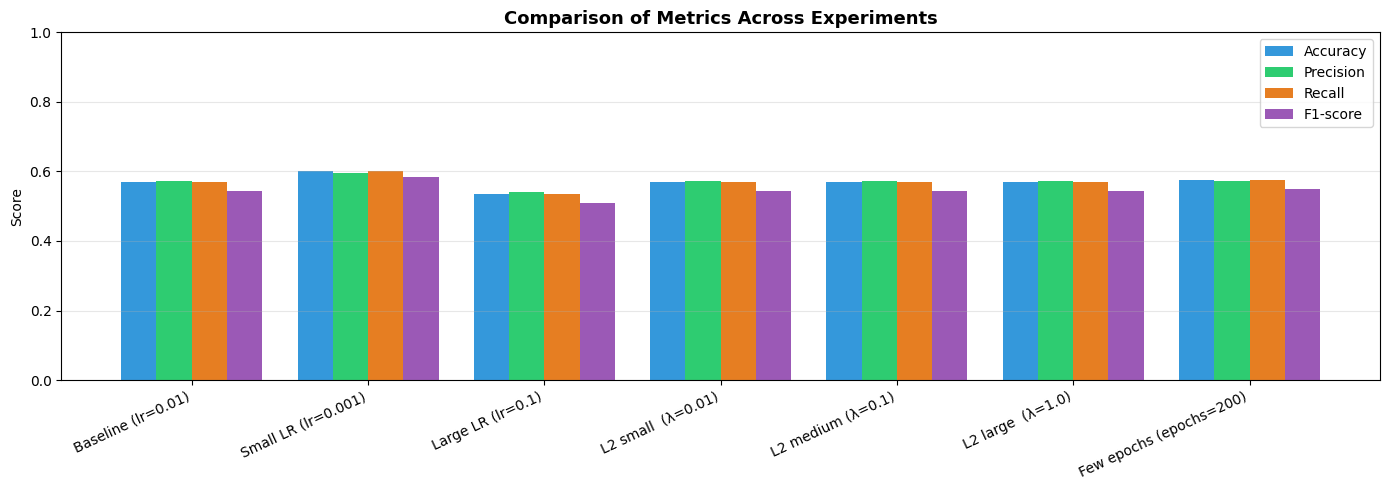

In [ ]:
# Bar chart: Accuracy / Precision / Recall / F1 
names  = [r['name'] for r in results]
accs   = [r['acc']  for r in results]
precs  = [r['prec'] for r in results]
recs   = [r['rec']  for r in results]
f1s    = [r['f1']   for r in results]

x = np.arange(len(names))
w = 0.2

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - 1.5*w, accs,  w, label='Accuracy',  color='#3498db')
ax.bar(x - 0.5*w, precs, w, label='Precision', color='#2ecc71')
ax.bar(x + 0.5*w, recs,  w, label='Recall',    color='#e67e22')
ax.bar(x + 1.5*w, f1s,   w, label='F1-score',  color='#9b59b6')

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Comparison of Metrics Across Experiments', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Overfitting Gap Table 
print(f"{'Experiment':<30} {'Train Loss':>11} {'Val Loss':>10} {'Gap':>8} {'Test Acc':>9}")
print('─' * 72)

for r in results:
    tl = r['train_losses'][-1]
    vl = r['val_losses'][-1]
    gap = vl - tl
    flag = '⚠️  OVERFIT' if gap > 0.05 else '✓ OK'
    print(f"{r['name']:<30} {tl:>11.4f} {vl:>10.4f} {gap:>+8.4f}  {r['acc']:>7.3f}  {flag}")

print('\n📌 Gap = Val Loss − Train Loss.  Gap > 0.05 → dấu hiệu overfitting.')


Experiment                      Train Loss   Val Loss      Gap  Test Acc
────────────────────────────────────────────────────────────────────────
Baseline (lr=0.01)                  0.9227     0.9924  +0.0697    0.569  ⚠️  OVERFIT
Small LR (lr=0.001)                 0.9049     0.9585  +0.0536    0.600  ⚠️  OVERFIT
Large LR (lr=0.1)                   1.1924     1.2129  +0.0205    0.534  ✓ OK
L2 small  (λ=0.01)                  1.2641     0.9924  -0.2717    0.569  ✓ OK
L2 medium (λ=0.1)                   4.3362     0.9924  -3.3438    0.569  ✓ OK
L2 large  (λ=1.0)                  35.0574     0.9924 -34.0650    0.569  ✓ OK
Few epochs (epochs=200)             0.9266     0.9756  +0.0490    0.575  ✓ OK

📌 Gap = Val Loss − Train Loss.  Gap > 0.05 → dấu hiệu overfitting.


Best model: Small LR (lr=0.001)  (Acc = 0.600)



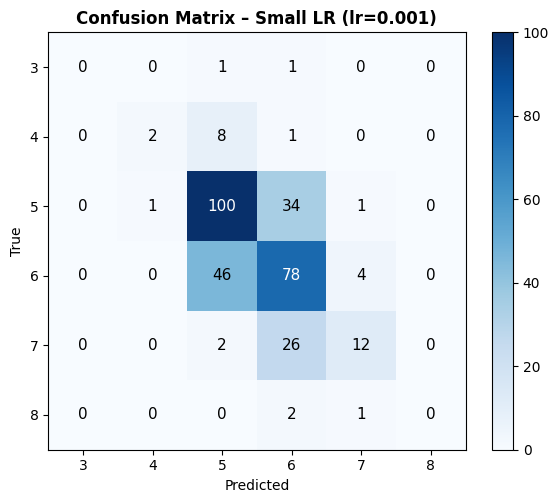

  Class 3: TP=  0  FP=  0  FN=  2  TN=318
  Class 4: TP=  2  FP=  1  FN=  9  TN=308
  Class 5: TP=100  FP= 57  FN= 36  TN=127
  Class 6: TP= 78  FP= 64  FN= 50  TN=128
  Class 7: TP= 12  FP=  6  FN= 28  TN=274
  Class 8: TP=  0  FP=  0  FN=  3  TN=317


In [ ]:
# Confusion Matrix – Best model (by accuracy) 
best = max(results, key=lambda r: r['acc'])
print(f"Best model: {best['name']}  (Acc = {best['acc']:.3f})\n")

cm = confusion_matrix(y_test, best['y_pred'])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im)
ax.set_title(f"Confusion Matrix – {best['name']}", fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=11)
plt.tight_layout()
plt.show()

# TP/FP/FN/TN
TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (TP + FP + FN)
for i, cls in enumerate(classes):
    print(f"  Class {cls}: TP={TP[i]:>3}  FP={FP[i]:>3}  FN={FN[i]:>3}  TN={TN[i]:>3}")


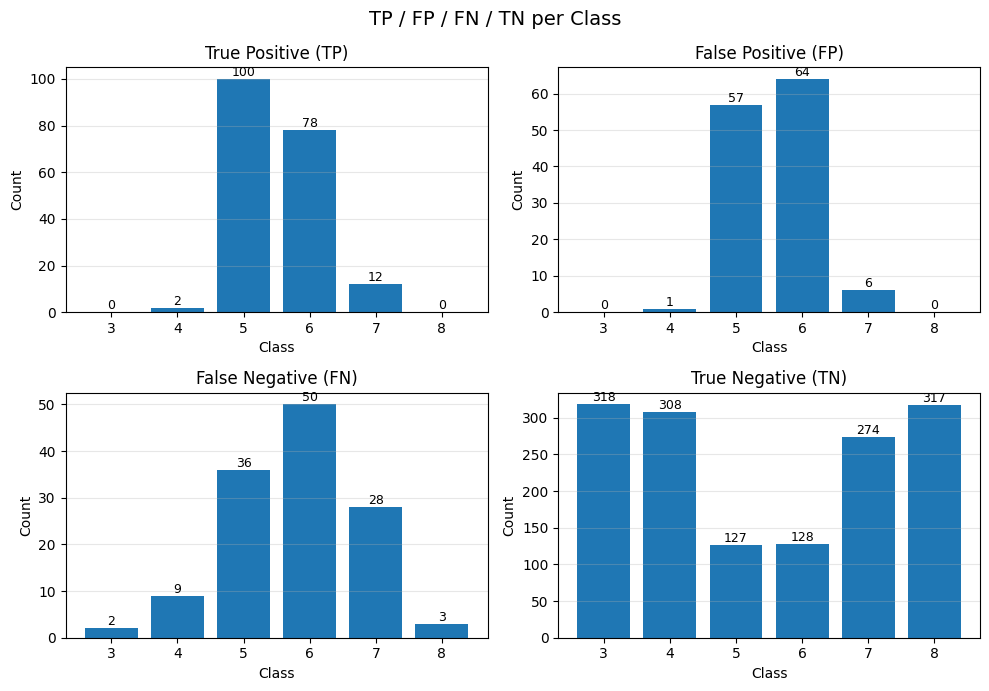

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(10,7))

metrics = [TP, FP, FN, TN]
titles = ["True Positive (TP)", "False Positive (FP)",
          "False Negative (FN)", "True Negative (TN)"]

for ax, data, title in zip(axs.flatten(), metrics, titles):
    bars = ax.bar(classes, data)
    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.suptitle("TP / FP / FN / TN per Class", fontsize=14)
plt.tight_layout()
plt.show()
